### Importing liberaries

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

###  Loading dataset

In [80]:
df = pd.read_csv(r"D:\GitHub\Netflix_EDA\mymoviedb.csv",lineterminator= "\n")
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


## Describing data 

In [81]:
df.info()  # as we can see the date of the movies are in object like 2021-12-22 this formate we need to change it to date time formate 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


In [82]:
df['Genre'].head() # we can see after each genre ther is comma(,) and a white space( ) we beed to remove that 

0    Action, Adventure, Science Fiction
1              Crime, Mystery, Thriller
2                              Thriller
3    Animation, Comedy, Family, Fantasy
4      Action, Adventure, Thriller, War
Name: Genre, dtype: object

In [83]:
df.duplicated().sum()

np.int64(0)

In [84]:
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


## Exploration Summary

. we have a dataframe consisting of 9827 rows and 9 columns.

. our dataset looks a bit tidy with no NaNs nor duplicated values.

. Release Date column needs to be casted into date time and to extract only the year value.

. Overview, Original_Languege and Poster-Url wouldn't be so useful during analysis, so we'll drop them.

. there is noticable outliers in Popularity column

. Vote_Average bettter be categorised for proper analysis.

. Genre column has comma saperated values and white spaces that needs to be handled and casted into category. Exploration Summary

## Data Pre-Processing

In [85]:
df['Release_Date']= pd.to_datetime(df['Release_Date'])  # changed release year data type from object to datetime
print(df['Release_Date'].dtype)

datetime64[ns]


In [86]:
df['Release_Date']=df['Release_Date'].dt.year  # as we only need year of releases date we have removed mth and date and kept only year
df['Release_Date'].dtype


dtype('int32')

In [87]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


#### dropping unnecessary columns


In [88]:
col =['Overview','Original_Language','Poster_Url']
df.drop(col, axis=1, inplace=True)


In [89]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


#### categorizing Vote_Average column
we are marking vote_average colum into 4 values popular ,average , below_avg, not_popular to describe it more using catogeriize_col() function


In [90]:
def categorize_col(df,col,labels):
    edges = [df[col].describe()['min'],
             df[col].describe()['25%'],
             df[col].describe()['50%'],
             df[col].describe()['75%'],
             df[col].describe()['max']]
    
    df[col]=pd.cut(df[col],edges, labels=labels,duplicates='drop')
    return df
    
    

In [91]:
labels = ['not_popular','below_avg','average','popular']
categorize_col(df, 'Vote_Average',labels)
df['Vote_Average'].unique()

['popular', 'below_avg', 'average', 'not_popular', NaN]
Categories (4, object): ['not_popular' < 'below_avg' < 'average' < 'popular']

In [92]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_avg,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


In [93]:
df['Vote_Average'].value_counts()

Vote_Average
not_popular    2467
popular        2450
average        2412
below_avg      2398
Name: count, dtype: int64

In [94]:
df.dropna(inplace=True)
df.isna().sum()

Release_Date    0
Title           0
Popularity      0
Vote_Count      0
Vote_Average    0
Genre           0
dtype: int64

#### we'd split genere into a list and then explode our dataframe to have only one genre per row for each movie 

In [95]:
df['Genre']=df['Genre'].str.split(', ')
df = df.explode('Genre').reset_index()
df.head()

,index,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,1,2022,The Batman,3827.658,1151,popular,Crime
4,1,2022,The Batman,3827.658,1151,popular,Mystery


In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25552 entries, 0 to 25551
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   index         25552 non-null  int64   
 1   Release_Date  25552 non-null  int32   
 2   Title         25552 non-null  object  
 3   Popularity    25552 non-null  float64 
 4   Vote_Count    25552 non-null  int64   
 5   Vote_Average  25552 non-null  category
 6   Genre         25552 non-null  object  
dtypes: category(1), float64(1), int32(1), int64(2), object(2)
memory usage: 1.1+ MB


In [99]:
# casting column into category

df['Genre']=df['Genre'].astype('category',)
df['Genre'].dtype,

(CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                   'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                   'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                   'TV Movie', 'Thriller', 'War', 'Western'],
 , ordered=False, categories_dtype=object),)

In [102]:
df.nunique()

index           9727
Release_Date     100
Title           9415
Popularity      8088
Vote_Count      3265
Vote_Average       4
Genre             19
dtype: int64

## Data Visualization

1) What is the most frequent genre of movies released on Netflix?

2) What genres has highest votes?

3) What movie got the highest popularity? what's its genre?

4) What movie got the lowest popularity? what's its genre?

5) Which year has the most filmmed movies?

In [105]:
sns.set_style('whitegrid')

In [103]:
df['Genre'].describe()

count     25552
unique       19
top       Drama
freq       3715
Name: Genre, dtype: object

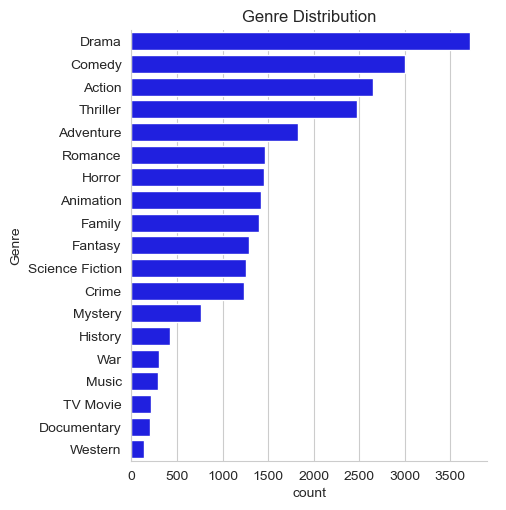

In [106]:
sns.catplot(y='Genre',data=df, kind='count',
            order= df['Genre'].value_counts().index,
            color='blue')
plt.title("Genre Distribution")
plt.show()